In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import scipy
import itertools
from scipy.integrate import odeint
# Reference: Grant Bunker, book 'The Phase Method' 2024
# if transitions in the Phase Plot are rounded in form
# (they should look like step-functions)
# then extend the range (decrease xmin, and increase xmax)
# if LSODA complains that too much accuracy is requested
# then reduce range (increase xmin, and decrease xmax)
#
# suggested improvements to this code:
# (to achieve some parity with Mathematica version)
# parallel mapping of bsearch
# extended precision computations
# improved graphics and output
#
#define potential energy function here
def U(x):
    uu=x**2/2
    return(uu)

#this is Schrödinger's equation as two coupled first order eqns    
def shrek(x, state, e):
    y, yprime = state
    dyprime = 2*(U(x)-e)*y
    dy = yprime
    return [dy, dyprime]

# this code plots the "Phase Plot" for a given energy
def plot_phaseplot(ee):
    y0 = [.01, .01]
    xgrid = np.arange(xmin, xmax, 0.01)
    result = odeint(shrek, y0, xgrid, (ee,), tfirst=True)
    phaseplot = np.tanh(result[:,0])
    plt.clf()
    plt.axhline( )
    plt.plot(xgrid,phaseplot)
    plt.title('energy='+str(ee),loc='center')
    plt.show()
    return()


#this code 'memo-izes' previously computed number-of-bound-states 
#values so they aren't unnecessarily recomputed -> 3x speed-up
#variable 'savednbs' is a python dictionary of key-value pairs
savednbs = {}
def nbs(ee):
    if (ee) in savednbs:
        return([ee,savednbs[ee]])
    y0 = [.1, .1]
    xgrid = np.arange(xmin,xmax, 0.01)
    result = odeint(shrek, y0, xgrid, (ee,), tfirst=True)
    t = np.diff(np.sign(np.tanh(result[:,0])))
    transitions = t[t!=0]/2
    nboundstates=len(transitions)
    savednbs[ee]=nboundstates
    return([ee, nboundstates])

def nstates(ee):
	return(nbs (ee)[1])

def bsearchnbs(intrvl):
    [low,high]=intrvl
    mid =(low+high)/2
    slow = nstates(low)
    shigh = nstates(high)
    smid = nstates(mid)
    newintervals = [ ]
    if slow < smid: 
        newintervals += [[low, mid]]
    if smid < shigh: 
        newintervals += [[mid, high]]
    return(newintervals)

def refine(intervals):
# this maps out the whole eigenvalue spectrum in an initial range 
# using a tree-like binary search
# intervals=[[0.,20.]] example starting interval nested list
# the mapping over the list of intervals would best be done 
# in parallel as in mathematica version
    print("starting interval=",intervals)
    nit=40; # max number of iterations; ~30-40 iterations is OK
    it=0; 
    while it <= nit:
        phaseplot=list(map(bsearchnbs,intervals));
        intervals = list(itertools. chain(*phaseplot));#flattens list
        if it%10==0:
           print("===>iteration=",it,";  nintervals=",\
           len(intervals),";  interval midpoints=")
           evals=list(map(np.mean,intervals))
           ngooddigits=7 #typical for 64 bit arithmetic
           roundit=lambda numb: np.round(numb,ngooddigits)
           print(list(map(roundit,evals)))
           print(" ")
        it=it+1
    phaseplot=list(map(np.mean,intervals))
    evals=list(map(roundit,phaseplot))
    return(evals)



In [5]:
savednbs

{30: 30,
 0: 0,
 15.0: 15,
 7.5: 7,
 22.5: 22,
 3.75: 4,
 11.25: 11,
 18.75: 19,
 26.25: 26,
 1.875: 2,
 5.625: 6,
 9.375: 9,
 13.125: 13,
 16.875: 17,
 20.625: 21,
 24.375: 24,
 28.125: 28,
 0.9375: 1,
 2.8125: 3,
 4.6875: 5,
 6.5625: 7,
 8.4375: 8,
 10.3125: 10,
 12.1875: 12,
 14.0625: 14,
 15.9375: 16,
 17.8125: 18,
 19.6875: 20,
 21.5625: 22,
 23.4375: 23,
 25.3125: 25,
 27.1875: 27,
 29.0625: 29,
 0.46875: 0,
 1.40625: 1,
 2.34375: 2,
 3.28125: 3,
 4.21875: 4,
 5.15625: 5,
 6.09375: 6,
 7.96875: 8,
 8.90625: 9,
 9.84375: 10,
 10.78125: 11,
 11.71875: 12,
 12.65625: 13,
 13.59375: 14,
 14.53125: 15,
 15.46875: 15,
 16.40625: 16,
 17.34375: 17,
 18.28125: 18,
 19.21875: 19,
 20.15625: 20,
 21.09375: 21,
 22.96875: 23,
 23.90625: 24,
 24.84375: 25,
 25.78125: 26,
 26.71875: 27,
 27.65625: 28,
 28.59375: 29,
 29.53125: 30,
 0.703125: 1,
 1.640625: 2,
 2.578125: 3,
 3.515625: 4,
 4.453125: 4,
 5.390625: 5,
 6.328125: 6,
 7.734375: 8,
 8.671875: 9,
 9.609375: 10,
 10.546875: 11,
 11.484

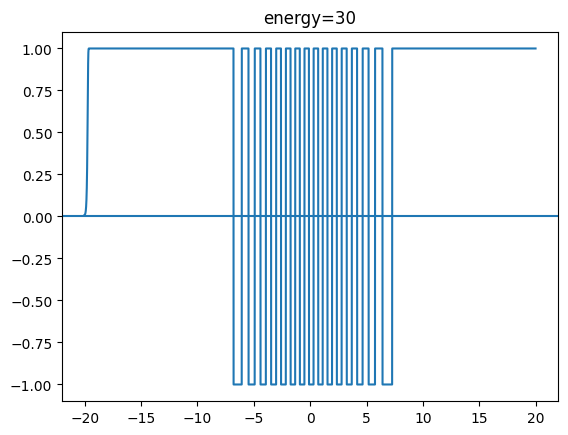

starting interval= [[0, 30]]
===>iteration= 0 ;  nintervals= 2 ;  interval midpoints=
[np.float64(7.5), np.float64(22.5)]
 
===>iteration= 10 ;  nintervals= 30 ;  interval midpoints=
[np.float64(0.5053711), np.float64(1.5014648), np.float64(2.4975586), np.float64(3.4936523), np.float64(4.5043945), np.float64(5.5004883), np.float64(6.496582), np.float64(7.5073242), np.float64(8.503418), np.float64(9.4995117), np.float64(10.4956055), np.float64(11.5063477), np.float64(12.5024414), np.float64(13.4985352), np.float64(14.4946289), np.float64(15.5053711), np.float64(16.5014648), np.float64(17.4975586), np.float64(18.4936523), np.float64(19.5043945), np.float64(20.5004883), np.float64(21.496582), np.float64(22.5073242), np.float64(23.503418), np.float64(24.4995117), np.float64(25.4956055), np.float64(26.5063477), np.float64(27.5024414), np.float64(28.4985352), np.float64(29.4946289)]
 
===>iteration= 20 ;  nintervals= 30 ;  interval midpoints=
[np.float64(0.4999995), np.float64(1.4999986), np

In [3]:
 # after executing the above code, the following commands 
 # can be entered into Jupyter (for example) to actually get results
(xmin,xmax) = (-20,20)  
startinginterval=[eminsearch,emaxsearch]=[0,30]
nbs(emaxsearch)  
plot_phaseplot(emaxsearch); 
intervals=[startinginterval]; #tees up starting interval for search
evals=refine(intervals); #does the search
print('*************','\nfinal eigenvalue estimates:')
print(evals)  #gives result
print('\nneigs=',len(evals))